In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Reviews.csv")

In [3]:
# Dataset shape
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and non-null values
print("\nDataset information:")
df.info()

Dataset shape: (568454, 10)

Columns:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [4]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
Id,0,0.000000
ProductId,0,0.000000
UserId,0,0.000000
ProfileName,26,0.004574
HelpfulnessNumerator,0,0.000000
HelpfulnessDenominator,0,0.000000
Score,0,0.000000
Time,0,0.000000
Summary,27,0.004750
Text,0,0.000000


In [6]:
print("Missing review texts:", df['Text'].isnull().sum())
print("Missing scores:", df['Score'].isnull().sum())

Missing review texts: 0
Missing scores: 0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (568454, 10)


In [9]:
print(df['Score'].value_counts().sort_index())

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


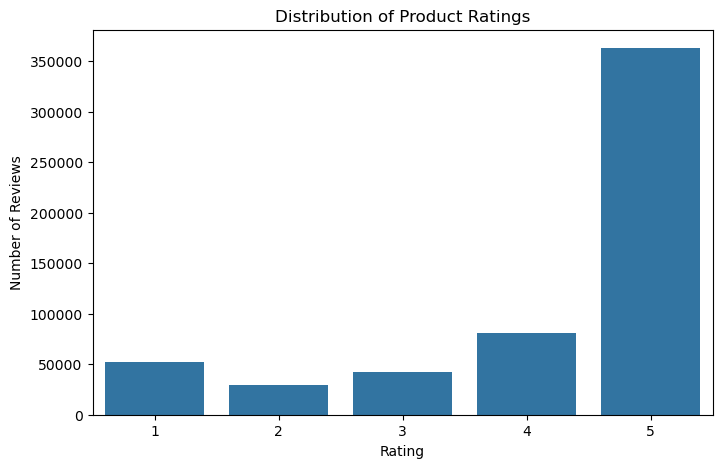

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Score')

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

In [11]:
# Remove neutral reviews
df = df[df['Score'] != 3].copy()

In [12]:
df['sentiment'] = df['Score'].apply(
    lambda x: 1 if x >= 4 else 0
)

In [13]:
df[['Score', 'sentiment']].head(10)

,Score,sentiment
0,5,1
1,1,0
2,4,1
3,2,0
4,5,1
5,4,1
6,5,1
7,5,1
8,5,1
9,5,1


In [14]:
print(df['sentiment'].value_counts())

sentiment
1    443777
0     82037
Name: count, dtype: int64


In [15]:
print(
    df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment
1    84.4
0    15.6
Name: proportion, dtype: float64


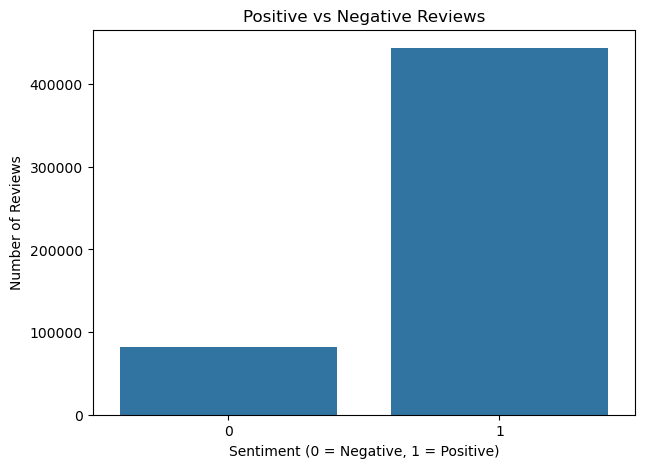

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='sentiment')

plt.title('Positive vs Negative Reviews')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')

plt.show()

In [17]:
df = df[['Text', 'Score', 'sentiment']].copy()

In [18]:
df.head()

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,0
2,This is a confection that has been around a fe...,4,1
3,If you are looking for the secret ingredient i...,2,0
4,Great taffy at a great price. There was a wid...,5,1


In [19]:
print("Missing Text values:", df['Text'].isnull().sum())

Missing Text values: 0


In [20]:
import re

In [21]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [22]:
df['cleaned_text'] = df['Text'].apply(clean_text)

In [23]:
df[['Text', 'cleaned_text']].head(10)

,Text,cleaned_text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...
5,I got a wild hair for taffy and ordered this f...,i got a wild hair for taffy and ordered this f...
6,This saltwater taffy had great flavors and was...,this saltwater taffy had great flavors and was...
7,This taffy is so good. It is very soft and ch...,this taffy is so good it is very soft and chew...
8,Right now I'm mostly just sprouting this so my...,right now im mostly just sprouting this so my ...
9,This is a very healthy dog food. Good for thei...,this is a very healthy dog food good for their...


In [24]:
df = df[df['cleaned_text'].str.len() > 10]

In [25]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\nSample reviews:")
display(df[['cleaned_text', 'sentiment']].head())

Final dataset shape: (525813, 4)

Missing values:
Text            0
Score           0
sentiment       0
cleaned_text    0
dtype: int64

Sentiment distribution:
sentiment
1    443776
0     82037
Name: count, dtype: int64

Sample reviews:


,cleaned_text,sentiment
0,i have bought several of the vitality canned d...,1
1,product arrived labeled as jumbo salted peanut...,0
2,this is a confection that has been around a fe...,1
3,if you are looking for the secret ingredient i...,0
4,great taffy at a great price there was a wide ...,1


In [26]:
import nltk

In [27]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to C:\Users\Asad
[nltk_data]     Computers\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Asad
[nltk_data]     Computers\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Asad
[nltk_data]     Computers\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
print(df['sentiment'].value_counts())

sentiment
1    443776
0     82037
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df,
    train_size=100000,
    stratify=df['sentiment'],
    random_state=42
)

df_sample = df_sample.reset_index(drop=True)

print("Sample size:", len(df_sample))
print(df_sample['sentiment'].value_counts())

Sample size: 100000
sentiment
1    84398
0    15602
Name: count, dtype: int64


In [30]:
from nltk.corpus import stopwords

In [31]:
stop_words = set(stopwords.words('english'))

negation_words = {'no', 'not', 'nor', 'never'}
stop_words = stop_words - negation_words

print("Number of Stopwords : " , len(stop_words)) 
print(list(stop_words)[:20])


Number of Stopwords :  195
['do', 't', "weren't", "it'd", 'will', 'here', "needn't", 'an', 'some', 'i', 'down', "we've", 'ourselves', 'how', 'each', 'those', 'itself', 'too', 'for', 'has']


In [32]:
print('not' in stop_words)
print('no' in stop_words)
print('never' in stop_words)

False
False
False


In [33]:
from nltk.tokenize import word_tokenize

In [34]:
def remove_stopwords(text):
    tokens = word_tokenize(text)
    
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    
    return ' '.join(filtered_tokens)

In [35]:
df_sample['processed_text'] = df_sample['cleaned_text'].apply(remove_stopwords)

In [36]:
df_sample[['cleaned_text', 'processed_text']].head(10)

,cleaned_text,processed_text
0,what can i say i love iced tea i drink a lot o...,say love iced tea drink lot love convenience n...
1,i enjoy a smooth flavorful cup of coffee espec...,enjoy smooth flavorful cup coffee especially f...
2,these are just wonderful i bought a small bag ...,wonderful bought small bag marshalls loved muc...
3,ive only tried the raspberry so far they are a...,ive tried raspberry far awesome naturally swee...
4,this illy issimo cappucino coffee drink is ver...,illy issimo cappucino coffee drink nice served...
5,my dogs have been eating these treats for some...,dogs eating treats time although love starting...
6,when i received this package today on the date...,received package today date jan looked back pr...
7,our pup loves these treats theyre working real...,pup loves treats theyre working really well tr...
8,thought this sounded weird at first but gave i...,thought sounded weird first gave shot glad did...
9,for licorice lovers only intense licorice flav...,licorice lovers intense licorice flavor natura...


In [37]:
example = df_sample['cleaned_text'].iloc[0]

tokens = word_tokenize(example)

print("Original:")
print(example)

print("\nTokens:")
print(tokens)

Original:
what can i say i love iced tea i drink a lot of it and love the convenience of these new individual serving size packets i am also a big fan of stash products or rather of all the other stash products i have triedi purchased a case of all varieties when i say i drink iced tea i am not kidding and these were all way too weak when i mixed them in my ounces water bottlei finally found that i needed to dissolve packets in a small bit of hot water first if not the tea clumped on me and than add a packet of sweetener before adding the rest of the water just to make these palatableunfortunately by doing that to this flavor the ginger was out of control and not in a good ginger tea sort of wayover all i am very dissatisfied with the product and will stick with the other brands that are out on the market

Tokens:
['what', 'can', 'i', 'say', 'i', 'love', 'iced', 'tea', 'i', 'drink', 'a', 'lot', 'of', 'it', 'and', 'love', 'the', 'convenience', 'of', 'these', 'new', 'individual', 'servin

In [38]:
X = df_sample['processed_text']
y = df_sample['sentiment']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 80000
Testing reviews: 20000


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [42]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [43]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [44]:
X_test_tfidf = tfidf.transform(X_test)

In [45]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (80000, 20000)
Testing TF-IDF shape: (20000, 20000)


In [46]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 20000

First 50 features:
['ability' 'able' 'able buy' 'able drink' 'able eat' 'able enjoy'
 'able find' 'able get' 'able give' 'able go' 'able make' 'able order'
 'able purchase' 'able take' 'able tell' 'able try' 'able use' 'absolute'
 'absolute best' 'absolute favorite' 'absolutely' 'absolutely amazing'
 'absolutely awful' 'absolutely best' 'absolutely delicious'
 'absolutely horrible' 'absolutely love' 'absolutely loved'
 'absolutely loves' 'absolutely no' 'absolutely not' 'absolutely nothing'
 'absolutely perfect' 'absolutely wonderful' 'absorb' 'absorbed'
 'absorbed small' 'absorbs' 'absorption' 'abundant' 'abundant mineral'
 'academy' 'academy sciences' 'acai' 'accept' 'acceptable' 'accepted'
 'accepted throughout' 'access' 'accident']


In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [49]:
lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [50]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [51]:
print("Predictions:", y_pred_lr[:20])
print("Actual:", y_test.values[:20])

Predictions: [1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1]
Actual: [1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1]


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [53]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.9314
Precision: 0.9357
Recall   : 0.9865
F1 Score : 0.9604


In [54]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.90      0.63      0.74      3120
    Positive       0.94      0.99      0.96     16880

    accuracy                           0.93     20000
   macro avg       0.92      0.81      0.85     20000
weighted avg       0.93      0.93      0.93     20000



In [55]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[ 1976  1144]
 [  228 16652]]


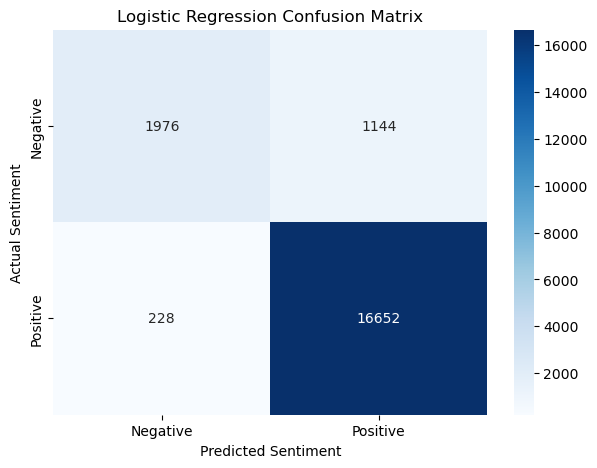

In [56]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

In [57]:
from sklearn.naive_bayes import MultinomialNB

In [58]:
nb_model = MultinomialNB()

In [59]:
nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [60]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [61]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

Naive Bayes Results
-------------------
Accuracy : 0.8993
Precision: 0.8974
Recall   : 0.9944
F1 Score : 0.9434


In [62]:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.93      0.38      0.54      3120
    Positive       0.90      0.99      0.94     16880

    accuracy                           0.90     20000
   macro avg       0.91      0.69      0.74     20000
weighted avg       0.90      0.90      0.88     20000



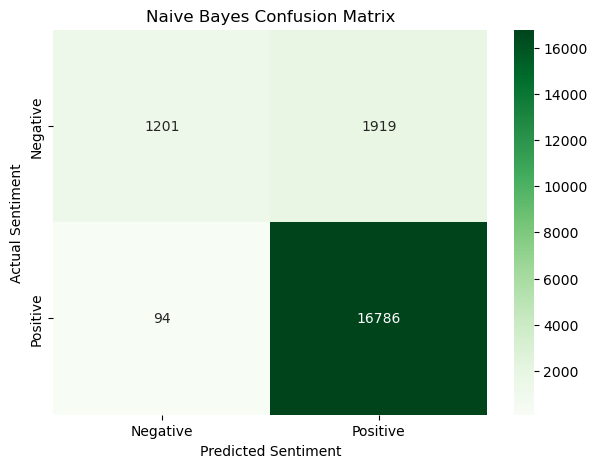

In [63]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

In [64]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_nb
    ],
    'Precision': [
        precision_lr,
        precision_nb
    ],
    'Recall': [
        recall_lr,
        recall_nb
    ],
    'F1 Score': [
        f1_lr,
        f1_nb
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9314,0.9357,0.9865,0.9604
1,Naive Bayes,0.8994,0.8974,0.9944,0.9434


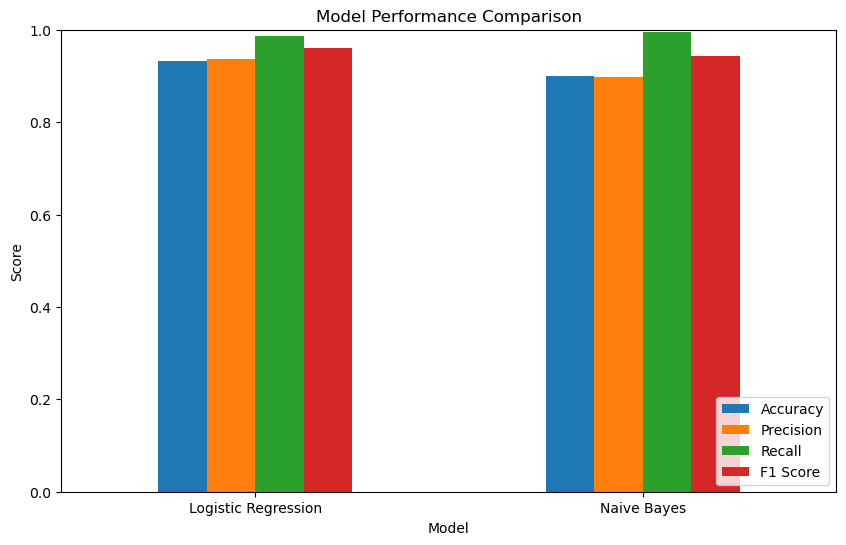

In [65]:
results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

In [66]:
def predict_sentiment(review):
    cleaned = clean_text(review)
    
    processed = remove_stopwords(cleaned)
    
    vectorized = tfidf.transform([processed])
    
    prediction = lr_model.predict(vectorized)[0]
    
    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [67]:
test_reviews = [
    "This product is amazing and works perfectly.",
    "I absolutely love this product.",
    "Terrible quality and a complete waste of money.",
    "The product broke after two days.",
    "Very good quality and excellent performance."
]

for review in test_reviews:
    print("Review:", review)
    print("Prediction:", predict_sentiment(review))
    print()

Review: This product is amazing and works perfectly.
Prediction: Positive

Review: I absolutely love this product.
Prediction: Positive

Review: Terrible quality and a complete waste of money.
Prediction: Negative

Review: The product broke after two days.
Prediction: Negative

Review: Very good quality and excellent performance.
Prediction: Positive

